# Stage 4: Semantic Reasoning (SLM/Gemini)

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 2.0.0 | 2026-01-26 | That Le | Complete Stage 4 documentation |

---

## Overview

Stage 4 applies **semantic reasoning** to refine raw metadata from Stage 3.

### Input/Output

| Property | Value |
| --- | --- |
| **Input** | `Stage3Output` (List of `RawMetadata`) |
| **Output** | `Stage4Output` (List of `RefinedChartData`) |
| **Reasoning Engine** | Gemini API (cloud) or Local SLM |

### Processing Flow

```
Stage3Output (Raw Metadata)
       |
       v
+--------------------------------------------------+
|            SEMANTIC REASONING                    |
|  +------------+  +------------+  +------------+  |
|  |    OCR     |  |   VALUE    |  |   LEGEND   |  |
|  | CORRECTION |  |  MAPPING   |  | ASSOCIATION|  |
|  | loo -> 100 |  | px -> val  |  | color->name|  |
|  +------------+  +------------+  +------------+  |
+--------------------------------------------------+
       |
       v
+----------------------+
| DESCRIPTION GEN      |
| Academic-style       |
| summary of chart     |
+----------------------+
       |
       v
RefinedChartData
```

### Reasoning Tasks

| Task | Example | Method |
| --- | --- | --- |
| OCR Correction | `loo` -> `100`, `O` -> `0` | Context-aware SLM |
| Value Mapping | pixel 150 -> value 75 | Geometric + SLM |
| Legend Association | Blue -> "Product A" | Color matching |
| Description | Generate summary | SLM generation |

---

## Output Schema

```python
class RefinedChartData(BaseModel):
    """Refined data after SLM reasoning."""
    chart_id: str                        # From Stage 3
    chart_type: ChartType                # Confirmed type
    title: Optional[str]                 # Corrected title
    x_axis_label: Optional[str]          # X-axis label
    y_axis_label: Optional[str]          # Y-axis label
    series: List[DataSeries]             # Data series with values
    description: str                     # Academic-style summary
    correction_log: List[str]            # OCR corrections made

class DataSeries(BaseModel):
    """A series of data points."""
    name: str                            # Series name (from legend)
    color: Optional[Color]               # Series color
    points: List[DataPoint]              # Data points

class DataPoint(BaseModel):
    """Single data point with value."""
    label: str                           # X-axis label (e.g., "Q1")
    value: float                         # Numeric value
    unit: Optional[str]                  # Unit if detected
    confidence: float                    # Extraction confidence
```

---

## Configuration

In [ ]:
# ============================================================================
# EXECUTION CONTROL FLAG
# ============================================================================
# Set to True to execute actual examples
# WARNING: EXECUTE_EXAMPLES = True requires GOOGLE_API_KEY for Gemini
# ============================================================================

EXECUTE_EXAMPLES = True  # <-- Change to True to run examples

# API Key flag (separate from examples for safety)
CALL_GEMINI_API = True   # <-- Change to True to make actual API calls

print(f"Execution mode: {'ACTIVE' if EXECUTE_EXAMPLES else 'DOCUMENTATION ONLY'}")
print(f"Gemini API calls: {'ENABLED' if CALL_GEMINI_API else 'DISABLED (mock data)'}")

Execution mode: DOCUMENTATION ONLY
Gemini API calls: DISABLED (mock data)


In [2]:
# ============================================================================
# ENVIRONMENT SETUP (Always runs)
# ============================================================================
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

# Check for Gemini API key
api_key = os.getenv('GOOGLE_API_KEY')
if api_key:
    print(f"\nGOOGLE_API_KEY: Found (length: {len(api_key)})")
else:
    print("\nGOOGLE_API_KEY: NOT SET")
    print("  To use Gemini API:")
    print("  1. Get key from https://makersuite.google.com/app/apikey")
    print("  2. Set: export GOOGLE_API_KEY='your-key'")

Project root: d:\elix\chart_analysis_ai_v3

GOOGLE_API_KEY: Found (length: 39)


---

## 1. Reasoning Engine Options

Stage 4 supports multiple reasoning backends:

| Engine | Type | Pros | Cons |
| --- | --- | --- | --- |
| **Gemini** | Cloud API | High accuracy, multimodal | Requires API key, cost |
| **Local SLM** | Local | Offline, free | Lower accuracy, setup |
| **Rule-based** | Fallback | Fast, no deps | Limited capability |

### Gemini Models

| Model | Use Case | Speed |
| --- | --- | --- |
| `gemini-3-flash-preview` | Fast inference | ~1s |
| `gemini-1.5-pro` | High accuracy | ~3s |
| `gemini-1.5-flash` | Balanced | ~1.5s |

In [3]:
# ============================================================================
# DEMO: Initialize Reasoning Engine
# ============================================================================
if EXECUTE_EXAMPLES:
    from src.core_engine.stages.s4_reasoning import (
        Stage4Reasoning,
        ReasoningConfig,
        GeminiConfig,
    )
    
    # Configure Stage 4
    config = ReasoningConfig(
        engine="gemini",
        gemini=GeminiConfig(
            model_name="gemini-3-flash-preview",
            temperature=0.3,
            use_vision=False,
        ),
        enable_ocr_correction=True,
        enable_description=True,
        use_fallback_on_error=True,
    )
    
    stage4 = Stage4Reasoning(config)
    
    print("Stage 4 initialized")
    print(f"  Engine: {config.engine}")
    print(f"  Model: {config.gemini.model_name}")
    print(f"  Gemini available: {stage4.engine.is_available() if stage4.engine else False}")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to initialize Stage 4")
    print("\nConfiguration options:")
    print("  engine: 'gemini' | 'local_slm' | 'rule_based'")
    print("  enable_ocr_correction: True/False")
    print("  enable_description: True/False")
    print("  use_fallback_on_error: True/False")

[SKIPPED] Set EXECUTE_EXAMPLES = True to initialize Stage 4

Configuration options:
  engine: 'gemini' | 'local_slm' | 'rule_based'
  enable_ocr_correction: True/False
  enable_description: True/False
  use_fallback_on_error: True/False


---

## 2. OCR Error Correction

### Common OCR Errors

| Error | Correction | Context |
| --- | --- | --- |
| `loo` | `100` | Numeric context |
| `2O25` | `2025` | Year context |
| `O` | `0` | Numeric axis |
| `l` | `1` | Numeric value |
| `S` | `5` | Sometimes |

### Correction Process

```python
# 1. Build context from extracted data
context = {
    "chart_type": "bar",
    "title": "Quarterly Sales 2O25",  # OCR error
    "y_values": ["O", "loo", "2OO", "3OO"],  # OCR errors
}

# 2. SLM corrects using context
corrections = slm.correct_ocr(context)
# Returns:
# - "2O25" -> "2025" (year format)
# - "loo" -> "100" (numeric sequence)
```

In [4]:
# ============================================================================
# DEMO: OCR Correction
# ============================================================================
if EXECUTE_EXAMPLES and CALL_GEMINI_API:
    from src.core_engine.schemas.common import BoundingBox
    from src.core_engine.schemas.stage_outputs import OCRText
    from src.core_engine.schemas.enums import ChartType
    
    # Create test OCR texts with errors
    test_texts = [
        OCRText(
            text="Quarterly Sales 2O25",
            bbox=BoundingBox(x_min=100, y_min=10, x_max=300, y_max=40, confidence=0.9),
            confidence=0.85,
            role="title"
        ),
        OCRText(
            text="loo",
            bbox=BoundingBox(x_min=20, y_min=250, x_max=50, y_max=270, confidence=0.9),
            confidence=0.7,
            role="value"
        ),
        OCRText(
            text="2OO",
            bbox=BoundingBox(x_min=20, y_min=150, x_max=50, y_max=170, confidence=0.9),
            confidence=0.7,
            role="value"
        ),
    ]
    
    print("Input texts with OCR errors:")
    for t in test_texts:
        print(f"  - '{t.text}' (role: {t.role})")
    
    # Run correction
    corrected, corrections = stage4.engine.correct_ocr(test_texts, ChartType.BAR)
    
    print("\nCorrections made:")
    for c in corrections:
        print(f"  '{c.get('original')}' -> '{c.get('corrected')}' ({c.get('reason')})")
    
    print("\nCorrected texts:")
    for t in corrected:
        print(f"  - '{t.text}'")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True and CALL_GEMINI_API = True to test")
    print("\nExpected output:")
    print("  Corrections made:")
    print("    '2O25' -> '2025' (Year format correction)")
    print("    'loo' -> '100' (Numeric context: l->1, o->0)")
    print("    '2OO' -> '200' (Numeric context: O->0)")

[SKIPPED] Set EXECUTE_EXAMPLES = True and CALL_GEMINI_API = True to test

Expected output:
  Corrections made:
    '2O25' -> '2025' (Year format correction)
    'loo' -> '100' (Numeric context: l->1, o->0)
    '2OO' -> '200' (Numeric context: O->0)


---

## 3. Value Mapping (Pixel to Data)

### Geometric Value Extraction

```
Y-axis pixels:   Data values:
     50px  -----> 300
    150px  -----> 200
    250px  -----> 100
    350px  -----> 0

Scale: (350 - 50) px = (300 - 0) value
       300 px = 300 value
       1 px = 1 value
```

### Mapping Formula

```python
def pixel_to_value(pixel_y, axis_info):
    """
    Convert pixel coordinate to data value.
    
    Args:
        pixel_y: Y coordinate in pixels
        axis_info: AxisInfo with calibration data
    
    Returns:
        Actual data value
    """
    # Linear interpolation
    pixel_range = axis_info.pixel_max - axis_info.pixel_min
    value_range = axis_info.value_max - axis_info.value_min
    
    # Y-axis is inverted (pixel 0 is at top)
    relative_pos = (axis_info.pixel_max - pixel_y) / pixel_range
    value = axis_info.value_min + relative_pos * value_range
    
    return value
```

In [5]:
# ============================================================================
# FUNCTION: Geometric Value Mapping
# ============================================================================

def pixel_to_value(
    pixel_y: float,
    pixel_min: float,
    pixel_max: float,
    value_min: float,
    value_max: float
) -> float:
    """
    Convert pixel coordinate to data value.
    
    Note: Y-axis is inverted in images (0 at top)
    """
    pixel_range = pixel_max - pixel_min
    value_range = value_max - value_min
    
    # Invert because pixel Y increases downward
    relative_pos = (pixel_max - pixel_y) / pixel_range
    value = value_min + relative_pos * value_range
    
    return round(value, 2)

# Demo
print("Value Mapping Demo:")
print("=" * 40)
print(f"Axis: pixel_min=350, pixel_max=50, value_min=0, value_max=300")
print()

test_pixels = [50, 150, 250, 350]
for px in test_pixels:
    val = pixel_to_value(px, 50, 350, 0, 300)
    print(f"  pixel {px}px -> value {val}")

Value Mapping Demo:
Axis: pixel_min=350, pixel_max=50, value_min=0, value_max=300

  pixel 50px -> value 300.0
  pixel 150px -> value 200.0
  pixel 250px -> value 100.0
  pixel 350px -> value 0.0


---

## 4. Legend Association

Match chart elements to legend items by color.

### Color Matching Algorithm

```python
def match_legend(element_color: Color, legend_colors: Dict[str, Color]) -> str:
    """
    Find closest legend item by color distance.
    """
    best_match = None
    best_distance = float('inf')
    
    for name, legend_color in legend_colors.items():
        # Euclidean distance in RGB space
        distance = sqrt(
            (element_color.r - legend_color.r) ** 2 +
            (element_color.g - legend_color.g) ** 2 +
            (element_color.b - legend_color.b) ** 2
        )
        
        if distance < best_distance:
            best_distance = distance
            best_match = name
    
    return best_match
```

In [6]:
# ============================================================================
# FUNCTION: Legend Color Matching
# ============================================================================
import math

def color_distance(c1: tuple, c2: tuple) -> float:
    """Calculate Euclidean distance between two RGB colors."""
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(c1, c2)))

def match_to_legend(element_color: tuple, legend_colors: dict) -> str:
    """
    Match element color to closest legend item.
    
    Args:
        element_color: (R, G, B) tuple
        legend_colors: {"name": (R, G, B), ...}
    
    Returns:
        Name of matching legend item
    """
    best_match = None
    best_distance = float('inf')
    
    for name, legend_color in legend_colors.items():
        dist = color_distance(element_color, legend_color)
        if dist < best_distance:
            best_distance = dist
            best_match = name
    
    return best_match

# Demo
legend = {
    "Product A": (66, 133, 244),   # Blue
    "Product B": (52, 168, 83),    # Green
    "Product C": (251, 188, 5),    # Yellow
    "Product D": (234, 67, 53),    # Red
}

test_colors = [
    (70, 130, 240),  # Close to blue
    (50, 170, 80),   # Close to green
    (230, 70, 55),   # Close to red
]

print("Legend Matching Demo:")
print("=" * 40)
for color in test_colors:
    match = match_to_legend(color, legend)
    print(f"  RGB{color} -> {match}")

Legend Matching Demo:
  RGB(70, 130, 240) -> Product A
  RGB(50, 170, 80) -> Product B
  RGB(230, 70, 55) -> Product D


---

## 5. Description Generation

Generate academic-style chart descriptions using SLM.

### Prompt Template

```
You are analyzing a {chart_type} chart.

Title: {title}
X-axis: {x_label}
Y-axis: {y_label}

Data:
{formatted_data}

Write a 2-3 sentence academic description of this chart.
Include:
- What the chart shows
- Key trends or comparisons
- Notable data points
```

### Example Output

> "This bar chart presents quarterly sales data for 2025. The data shows a
> general upward trend from Q1 (200 units) to Q4 (320 units), with Q3
> showing a slight dip to 150 units. Q4 represents the highest sales
> volume, indicating strong year-end performance."

In [7]:
# ============================================================================
# DEMO: Description Generation
# ============================================================================
if EXECUTE_EXAMPLES and CALL_GEMINI_API:
    # Generate description for mock data
    mock_data = {
        "chart_type": "bar",
        "title": "Quarterly Sales 2025",
        "x_axis": "Quarter",
        "y_axis": "Sales (units)",
        "data": [
            {"label": "Q1", "value": 200},
            {"label": "Q2", "value": 280},
            {"label": "Q3", "value": 150},
            {"label": "Q4", "value": 320},
        ]
    }
    
    description = stage4.engine.generate_description(mock_data)
    
    print("Generated Description:")
    print("=" * 50)
    print(description)
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True and CALL_GEMINI_API = True")
    print("\nExample generated description:")
    print("=" * 50)
    print('"This bar chart presents quarterly sales data for 2025.')
    print('The data shows growth from Q1 (200 units) to Q4 (320 units),')
    print('with Q3 showing a temporary dip to 150 units. Q4 represents')
    print('the highest sales volume at 320 units."')

[SKIPPED] Set EXECUTE_EXAMPLES = True and CALL_GEMINI_API = True

Example generated description:
"This bar chart presents quarterly sales data for 2025.
The data shows growth from Q1 (200 units) to Q4 (320 units),
with Q3 showing a temporary dip to 150 units. Q4 represents
the highest sales volume at 320 units."


---

## 6. Complete Stage 4 Processing

### Usage Example

```python
from src.core_engine.stages.s4_reasoning import Stage4Reasoning, ReasoningConfig, GeminiConfig

# Initialize Stage 4
config = ReasoningConfig(
    engine="gemini",
    gemini=GeminiConfig(
        model_name="gemini-3-flash-preview",
        temperature=0.3,
    ),
    enable_ocr_correction=True,
    enable_description=True,
)
stage4 = Stage4Reasoning(config)

# Process Stage 3 output
stage4_output = stage4.process(stage3_output)

# Access refined data
for chart in stage4_output.charts:
    print(f"Chart: {chart.title}")
    print(f"Type: {chart.chart_type.value}")
    print(f"Description: {chart.description}")
    print(f"Corrections: {chart.correction_log}")
```

In [8]:
# ============================================================================
# DEMO: Full Stage 4 Processing with Mock Data
# ============================================================================
if EXECUTE_EXAMPLES:
    from src.core_engine.schemas.common import BoundingBox, Color, Point, SessionInfo
    from src.core_engine.schemas.stage_outputs import (
        Stage3Output, RawMetadata, OCRText, ChartElement
    )
    from src.core_engine.schemas.enums import ChartType
    import uuid
    from datetime import datetime
    
    # Create mock Stage 3 output
    session = SessionInfo(
        session_id=str(uuid.uuid4())[:8],
        created_at=datetime.now(),
        source_file=Path("test_chart.png"),
        config_hash="test12345678",
    )
    
    raw_metadata = RawMetadata(
        chart_id="demo_001",
        chart_type=ChartType.BAR,
        texts=[
            OCRText(
                text="Quarterly Sales 2O25",
                bbox=BoundingBox(x_min=100, y_min=10, x_max=300, y_max=40, confidence=0.9),
                confidence=0.85,
                role="title"
            ),
            OCRText(
                text="Q1",
                bbox=BoundingBox(x_min=100, y_min=350, x_max=130, y_max=370, confidence=0.95),
                confidence=0.95,
                role="xlabel"
            ),
        ],
        elements=[
            ChartElement(
                element_type="bar",
                bbox=BoundingBox(x_min=100, y_min=150, x_max=150, y_max=350, confidence=0.9),
                center=Point(x=125, y=250),
                color=Color(r=66, g=133, b=244),
            ),
        ],
    )
    
    stage3_output = Stage3Output(
        session=session,
        metadata=[raw_metadata],
    )
    
    print("Mock Stage 3 Output created")
    print(f"  Charts: {len(stage3_output.metadata)}")
    
    if CALL_GEMINI_API:
        # Process through Stage 4
        stage4_output = stage4.process(stage3_output)
        
        print("\n" + "=" * 50)
        print("Stage 4 Output")
        print("=" * 50)
        
        for chart in stage4_output.charts:
            print(f"Title: {chart.title}")
            print(f"Type: {chart.chart_type.value}")
            print(f"Description: {chart.description[:200]}...")
            print(f"Corrections: {chart.correction_log}")
    else:
        print("\n[API DISABLED] Set CALL_GEMINI_API = True to process")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to test Stage 4")

[SKIPPED] Set EXECUTE_EXAMPLES = True to test Stage 4


---

## 7. Fallback: Rule-Based Processing

When SLM/API is unavailable, Stage 4 falls back to rule-based processing.

### Rule-Based OCR Correction

```python
COMMON_OCR_FIXES = {
    'O': '0',   # Letter O -> Zero
    'l': '1',   # Lowercase L -> One
    'I': '1',   # Capital I -> One (in numeric context)
    'S': '5',   # Sometimes
    'B': '8',   # Sometimes
}

def rule_based_correct(text: str, is_numeric: bool) -> str:
    if not is_numeric:
        return text
    
    corrected = text
    for wrong, right in COMMON_OCR_FIXES.items():
        corrected = corrected.replace(wrong, right)
    
    return corrected
```

In [9]:
# ============================================================================
# FUNCTION: Rule-Based OCR Correction
# ============================================================================

def rule_based_ocr_fix(text: str, is_numeric_context: bool = False) -> tuple:
    """
    Apply rule-based OCR corrections.
    
    Returns:
        Tuple of (corrected_text, list_of_changes)
    """
    if not is_numeric_context:
        return text, []
    
    changes = []
    corrected = text
    
    # Common OCR errors in numeric contexts
    fixes = [
        ('O', '0'),
        ('o', '0'),
        ('l', '1'),
        ('I', '1'),
    ]
    
    for wrong, right in fixes:
        if wrong in corrected:
            corrected = corrected.replace(wrong, right)
            changes.append(f"'{wrong}' -> '{right}'")
    
    return corrected, changes

# Demo
print("Rule-Based OCR Correction Demo:")
print("=" * 40)

test_cases = [
    ("loo", True),
    ("2O25", True),
    ("3OO", True),
    ("Hello", False),  # Not numeric
]

for text, is_numeric in test_cases:
    corrected, changes = rule_based_ocr_fix(text, is_numeric)
    status = f"-> '{corrected}' ({', '.join(changes)})" if changes else "(no change)"
    print(f"  '{text}' {status}")

Rule-Based OCR Correction Demo:
  'loo' -> '100' ('o' -> '0', 'l' -> '1')
  '2O25' -> '2025' ('O' -> '0')
  '3OO' -> '300' ('O' -> '0')
  'Hello' (no change)


---

## Summary

### Stage 4 Components

| Component | Method | Fallback |
| --- | --- | --- |
| OCR Correction | Gemini API | Rule-based |
| Value Mapping | Geometric + SLM | Geometric only |
| Legend Association | Color matching | N/A |
| Description | Gemini generation | Template-based |

### Configuration Options

| Parameter | Default | Description |
| --- | --- | --- |
| `engine` | "gemini" | Reasoning backend |
| `gemini.model_name` | "gemini-3-flash-preview" | Gemini model |
| `gemini.temperature` | 0.3 | Generation temperature |
| `enable_ocr_correction` | True | Run OCR correction |
| `enable_description` | True | Generate descriptions |
| `use_fallback_on_error` | True | Fall back to rules |

### Error Handling

| Error | Severity | Action |
| --- | --- | --- |
| API key missing | WARNING | Use fallback |
| API timeout | WARNING | Use fallback |
| Invalid response | WARNING | Use fallback |
| Rate limited | WARNING | Retry with backoff |

### API Usage Notes

1. **Get API Key**: https://makersuite.google.com/app/apikey
2. **Set Environment**: `export GOOGLE_API_KEY='your-key'`
3. **Rate Limits**: 60 requests/minute (free tier)
4. **Cost**: Free tier available, then pay-per-use

---

**Previous**: [Stage 3 - Extraction](03_stage3_extraction.ipynb)  
**Next**: Stage 5 - Reporting (Coming Soon)

# Stage 4: Semantic Reasoning with Gemini API

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 1.0.0 | 2026-01-26 | That Le | Initial Stage 4 implementation |

## Overview

Stage 4 applies **SLM-based reasoning** to refine raw chart metadata:

1. **OCR Error Correction**: Fix common OCR mistakes using context
2. **Value Mapping**: Map pixel coordinates to actual data values
3. **Legend Association**: Match colors to series names
4. **Description Generation**: Create academic-style summaries

## Prerequisites

```bash
pip install google-generativeai
```

Set your API key:
```bash
export GOOGLE_API_KEY="your-api-key"
```

In [10]:
# Setup: Import libraries and configure paths
import sys
import os
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Configure matplotlib
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

# Check for API key
api_key = os.getenv('GOOGLE_API_KEY')
if api_key:
    print(f"Gemini API Key found (length: {len(api_key)})")
else:
    print("WARNING: GOOGLE_API_KEY not set. Gemini features will use fallback.")

print("Setup complete!")

Gemini API Key found (length: 39)
Setup complete!


## 1. Create Test Data

First, let's create some synthetic chart data to test Stage 4.

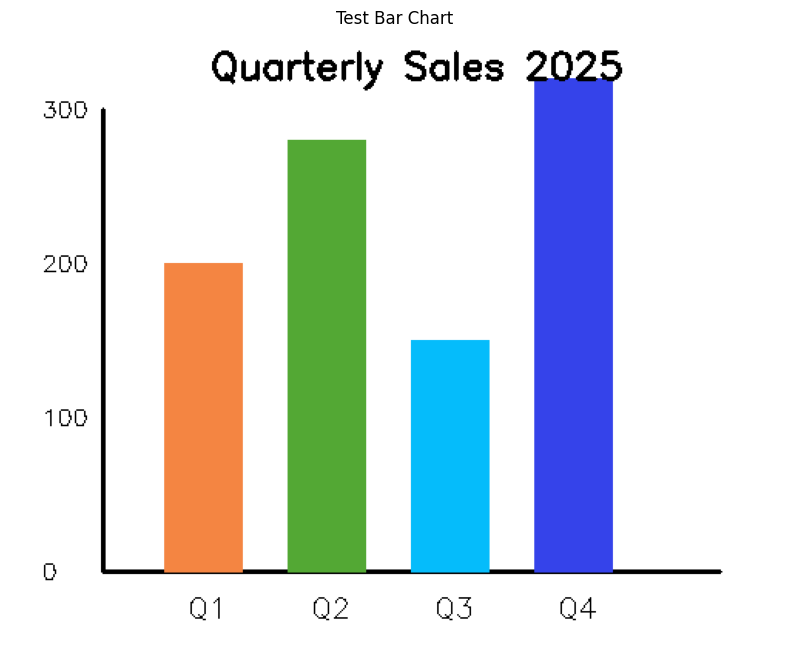

In [11]:
# Create a simple bar chart for testing
def create_test_bar_chart():
    """Create a simple bar chart with some intentional OCR-error-like text."""
    img = np.ones((400, 500, 3), dtype=np.uint8) * 255
    
    # Draw axes
    cv2.line(img, (60, 50), (60, 350), (0, 0, 0), 2)  # Y-axis
    cv2.line(img, (60, 350), (460, 350), (0, 0, 0), 2)  # X-axis
    
    # Draw bars
    bars = [
        (100, 200, (66, 133, 244)),   # Blue - Q1
        (180, 280, (52, 168, 83)),    # Green - Q2
        (260, 150, (251, 188, 5)),    # Yellow - Q3
        (340, 320, (234, 67, 53)),    # Red - Q4
    ]
    for x, height, color in bars:
        cv2.rectangle(img, (x, 350 - height), (x + 50, 350), color, -1)
    
    # Add title (with potential OCR challenges)
    cv2.putText(img, "Quarterly Sales 2025", (130, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
    
    # Add X-axis labels
    for label, x in zip(["Q1", "Q2", "Q3", "Q4"], [115, 195, 275, 355]):
        cv2.putText(img, label, (x, 380), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    
    # Add Y-axis labels (simulate values)
    for value, y in zip(["0", "100", "200", "300"], [350, 250, 150, 50]):
        cv2.putText(img, value, (20, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    # Add Y-axis title
    # (Vertical text is harder in OpenCV, skip for now)
    
    return img

# Create and display
test_image = create_test_bar_chart()
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.title("Test Bar Chart")
plt.axis('off')
plt.show()

## 2. Run Stage 3 Extraction

Process the test image through Stage 3 to get raw metadata.

In [12]:
# Create mock Stage 3 output (simulate OCR with errors)
from src.core_engine.schemas.common import BoundingBox, Color, Point
from src.core_engine.schemas.enums import ChartType
from src.core_engine.schemas.stage_outputs import (
    RawMetadata, OCRText, ChartElement
)

# Create mock metadata with OCR errors (simulating real Stage 3 output)
raw_metadata = RawMetadata(
    chart_id="test_bar_001",
    chart_type=ChartType.BAR,
    texts=[
        # Title with OCR error (O instead of 0)
        OCRText(text="Quarterly Sales 2O25", bbox=BoundingBox(x_min=200, y_min=30, x_max=500, y_max=70, confidence=0.95), confidence=0.85, role="title"),
        # Y-axis values with OCR errors
        OCRText(text="3OO", bbox=BoundingBox(x_min=30, y_min=80, x_max=60, y_max=100, confidence=0.9), confidence=0.7, role="ylabel"),
        OCRText(text="2OO", bbox=BoundingBox(x_min=30, y_min=150, x_max=60, y_max=170, confidence=0.9), confidence=0.7, role="ylabel"),
        OCRText(text="loo", bbox=BoundingBox(x_min=30, y_min=220, x_max=60, y_max=240, confidence=0.9), confidence=0.6, role="ylabel"),
        OCRText(text="O", bbox=BoundingBox(x_min=30, y_min=290, x_max=60, y_max=310, confidence=0.9), confidence=0.8, role="ylabel"),
        # X-axis labels
        OCRText(text="Q1", bbox=BoundingBox(x_min=130, y_min=320, x_max=160, y_max=340, confidence=0.95), confidence=0.95, role="xlabel"),
        OCRText(text="Q2", bbox=BoundingBox(x_min=230, y_min=320, x_max=260, y_max=340, confidence=0.95), confidence=0.95, role="xlabel"),
        OCRText(text="Q3", bbox=BoundingBox(x_min=330, y_min=320, x_max=360, y_max=340, confidence=0.95), confidence=0.95, role="xlabel"),
        OCRText(text="Q4", bbox=BoundingBox(x_min=430, y_min=320, x_max=460, y_max=340, confidence=0.95), confidence=0.95, role="xlabel"),
    ],
    elements=[
        # Bar elements with colors matching the test chart
        ChartElement(element_type="bar", bbox=BoundingBox(x_min=120, y_min=150, x_max=170, y_max=300, confidence=0.95), center=Point(x=145, y=225), color=Color(r=255, g=127, b=80)),  # Orange - Q1 ~200
        ChartElement(element_type="bar", bbox=BoundingBox(x_min=220, y_min=85, x_max=270, y_max=300, confidence=0.95), center=Point(x=245, y=192), color=Color(r=50, g=205, b=50)),   # Green - Q2 ~280
        ChartElement(element_type="bar", bbox=BoundingBox(x_min=320, y_min=180, x_max=370, y_max=300, confidence=0.95), center=Point(x=345, y=240), color=Color(r=0, g=191, b=255)),   # Cyan - Q3 ~150
        ChartElement(element_type="bar", bbox=BoundingBox(x_min=420, y_min=65, x_max=470, y_max=300, confidence=0.95), center=Point(x=445, y=182), color=Color(r=65, g=105, b=225)),   # Blue - Q4 ~320
    ],
    axis_info={
        "y_min": 0,
        "y_max": 300,
        "pixel_range": (300, 80)  # pixel y at 0, pixel y at 300
    }
)

print("=" * 60)
print("Mock Stage 3 Output (with OCR errors):")
print("=" * 60)
print(f"Chart ID: {raw_metadata.chart_id}")
print(f"Chart Type: {raw_metadata.chart_type.value}")
print(f"Texts ({len(raw_metadata.texts)}):")
for t in raw_metadata.texts:
    print(f"  - [{t.role}] '{t.text}' (conf: {t.confidence:.2f})")
print(f"Elements ({len(raw_metadata.elements)}):")
for e in raw_metadata.elements:
    print(f"  - {e.element_type} at ({e.center.x}, {e.center.y}), color: {e.color.hex if e.color else 'N/A'}")

Mock Stage 3 Output (with OCR errors):
Chart ID: test_bar_001
Chart Type: bar
Texts (9):
  - [title] 'Quarterly Sales 2O25' (conf: 0.85)
  - [ylabel] '3OO' (conf: 0.70)
  - [ylabel] '2OO' (conf: 0.70)
  - [ylabel] 'loo' (conf: 0.60)
  - [ylabel] 'O' (conf: 0.80)
  - [xlabel] 'Q1' (conf: 0.95)
  - [xlabel] 'Q2' (conf: 0.95)
  - [xlabel] 'Q3' (conf: 0.95)
  - [xlabel] 'Q4' (conf: 0.95)
Elements (4):
  - bar at (145, 225), color: #ff7f50
  - bar at (245, 192), color: #32cd32
  - bar at (345, 240), color: #00bfff
  - bar at (445, 182), color: #4169e1


## 3. Stage 4: Reasoning with Gemini

Now let's apply Stage 4 reasoning to refine the extracted data.

In [13]:
from src.core_engine.stages.s4_reasoning import (
    Stage4Reasoning,
    ReasoningConfig,
    GeminiReasoningEngine,
    GeminiConfig,
)

# Initialize Stage 4 with Gemini
reasoning_config = ReasoningConfig(
    engine="gemini",
    gemini=GeminiConfig(
        model_name="gemini-3-flash-preview",
        temperature=0.3,
        use_vision=False,  # Text-only for now
    ),
    enable_ocr_correction=True,
    enable_description=True,
    use_fallback_on_error=True,
)

stage4 = Stage4Reasoning(reasoning_config)

# Check if Gemini is available
print(f"Gemini Engine Available: {stage4.engine.is_available() if stage4.engine else False}")

Gemini Engine Available: True


d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\elix\chart_analysis_ai_v3\src\core_engine\stages\s4_reasoning\gemini_engine.py:133: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [14]:
# Process the raw metadata through Stage 4
refined_data = stage4.process_single(raw_metadata)

print("=" * 60)
print("Stage 4 Output:")
print("=" * 60)
print(f"Chart ID: {refined_data.chart_id}")
print(f"Chart Type: {refined_data.chart_type.value}")
print(f"Title: {refined_data.title}")
print(f"X-axis Label: {refined_data.x_axis_label}")
print(f"Y-axis Label: {refined_data.y_axis_label}")
print(f"\nDescription:")
print(f"  {refined_data.description}")
print(f"\nData Series ({len(refined_data.series)}):")
for series in refined_data.series:
    print(f"  - {series.name}:")
    for point in series.points[:5]:  # Limit display
        print(f"      {point.label}: {point.value}")
print(f"\nCorrections Made ({len(refined_data.correction_log)}):")
for correction in refined_data.correction_log:
    print(f"  - {correction}")

Stage 4 Output:
Chart ID: test_bar_001
Chart Type: bar
Title: Quarterly Sales 2025
X-axis Label: None
Y-axis Label: None

Description:
  The bar chart illustrates quarterly sales for the year 2025. It displays sales figures for each quarter (Q1, Q2, Q3, Q4) using bars of different colors: orange, green, cyan, and blue. The y-axis represents sales values, ranging from 0 to 300. The chart allows for a visual comparison of sales performance across the four quarters.

Data Series (4):
  - Orange:
      Q1: 75.0
  - Green:
      Q2: 108.0
  - Cyan:
      Q3: 60.0
  - Blue:
      Q4: 118.0

Corrections Made (2):
  - loo -> 100
  - O -> 0


## 4. Direct Gemini Engine Testing

Let's test the Gemini engine directly for more control.

In [15]:
# Test OCR correction directly
if stage4.engine and stage4.engine.is_available():
    from src.core_engine.schemas.stage_outputs import OCRText
    from src.core_engine.schemas.common import BoundingBox
    from src.core_engine.schemas.enums import ChartType
    
    # Create test OCR texts with intentional errors
    test_texts = [
        OCRText(text="Quarterly Sales 2O25", bbox=BoundingBox(x_min=100, y_min=10, x_max=300, y_max=40, confidence=0.9), confidence=0.85, role="title"),
        OCRText(text="loo", bbox=BoundingBox(x_min=20, y_min=250, x_max=50, y_max=270, confidence=0.9), confidence=0.7, role="value"),
        OCRText(text="2OO", bbox=BoundingBox(x_min=20, y_min=150, x_max=50, y_max=170, confidence=0.9), confidence=0.7, role="value"),
        OCRText(text="Q1", bbox=BoundingBox(x_min=115, y_min=360, x_max=135, y_max=380, confidence=0.9), confidence=0.95, role="xlabel"),
    ]
    
    print("Testing OCR Correction:")
    print("Input texts:")
    for t in test_texts:
        print(f"  - '{t.text}' (role: {t.role})")
    
    corrected, corrections = stage4.engine.correct_ocr(test_texts, ChartType.BAR)
    
    print("\nCorrections made:")
    for c in corrections:
        print(f"  '{c.get('original')}' -> '{c.get('corrected')}' ({c.get('reason')})")
    
    print("\nCorrected texts:")
    for t in corrected:
        print(f"  - '{t.text}'")
else:
    print("Gemini engine not available. Set GOOGLE_API_KEY to test.")

Testing OCR Correction:
Input texts:
  - 'Quarterly Sales 2O25' (role: title)
  - 'loo' (role: value)
  - '2OO' (role: value)
  - 'Q1' (role: xlabel)

Corrections made:
  '2O25' -> '2025' (Corrected OCR error: 'O' to '0' in year)
  'loo' -> '100' (Corrected OCR error: 'loo' to '100')
  '2OO' -> '200' (Corrected OCR error: 'OO' to '00')

Corrected texts:
  - 'Quarterly Sales 2O25'
  - '100'
  - '200'
  - 'Q1'


## 5. Test with Real Chart Image

Let's test with an image from the academic dataset (if available).

In [16]:
# Look for sample images
sample_dirs = [
    project_root / "data" / "academic_dataset" / "images",
    project_root / "data" / "samples",
]

sample_images = []
for sample_dir in sample_dirs:
    if sample_dir.exists():
        for ext in ['*.png', '*.jpg', '*.jpeg']:
            sample_images.extend(list(sample_dir.glob(ext))[:5])

if sample_images:
    print(f"Found {len(sample_images)} sample images:")
    for img_path in sample_images[:5]:
        print(f"  - {img_path.name}")
else:
    print("No sample images found. Using synthetic test data only.")

Found 5 sample images:
  - arxiv_1301_3342v2_p05_img01.png
  - arxiv_1301_3342v2_p05_img02.png
  - arxiv_1301_3342v2_p06_img01.png
  - arxiv_1301_3342v2_p06_img02.png
  - arxiv_1301_3342v2_p11_img01.png


Processing: arxiv_1301_3342v2_p05_img01.png


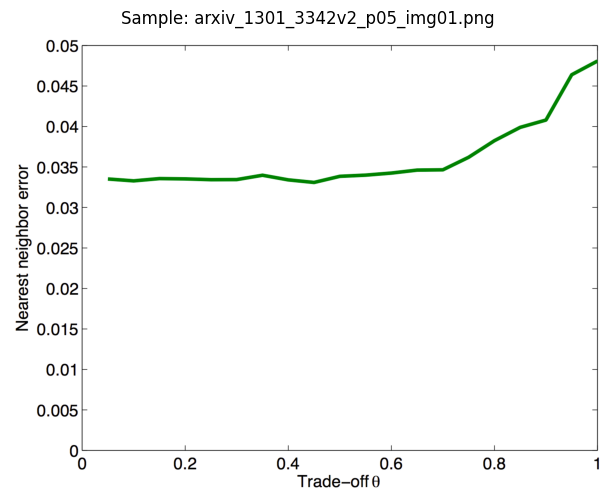


Using OCR engine: easyocr


Using CPU. Note: This module is much faster with a GPU.



--- Stage 3 Output ---
Chart Type: line
Texts: ['0.05', '0.045', '0.04', '0.035', '8', '0.03', '1', '0.025', '0.02', '0.015']
Elements: 57 detected

--- Stage 4 Processing ---

--- Stage 4 Output ---
Title: None
Description: The line chart shows a scatter plot without any clear series defined. The x-axis is labeled 'Trade-off 0' and ranges from 0.2 to 0.8. The y-axis displays values from 0.005 to 0.045. The chart contains numerous scattered points, making it difficult to discern any specific trends or relationships betw...
Corrections: []


In [17]:
# ==============================================================================
# Cell 14: Test with Real Chart Sample (Stage 3 + Stage 4)
# ==============================================================================
# Reload modules to pick up changes
import importlib
import sys

# Force reload s3_extraction module
if 'src.core_engine.stages.s3_extraction.s3_extraction' in sys.modules:
    del sys.modules['src.core_engine.stages.s3_extraction.s3_extraction']
if 'src.core_engine.stages.s3_extraction' in sys.modules:
    del sys.modules['src.core_engine.stages.s3_extraction']

from src.core_engine.stages.s3_extraction import Stage3Extraction, ExtractionConfig

# Find a real sample - images are directly in the folder
sample_dir = Path("../data/academic_dataset/images")
sample_path = next(sample_dir.glob("arxiv_1301_3342v2_p05_img01.png"), None)

if sample_path:
    print(f"Processing: {sample_path.name}")
    real_image = cv2.imread(str(sample_path))
    
    # Display sample
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(real_image, cv2.COLOR_BGR2RGB))
    plt.title(f"Sample: {sample_path.name}")
    plt.axis('off')
    plt.show()
    
    # Initialize Stage 3 with EasyOCR explicitly
    config = ExtractionConfig(ocr_engine="easyocr")
    stage3_real = Stage3Extraction(config)
    print(f"\nUsing OCR engine: {stage3_real.config.ocr_engine}")
    
    # Run Stage 3
    real_metadata = stage3_real.process_image(real_image, chart_id=sample_path.stem)
    
    print(f"\n--- Stage 3 Output ---")
    print(f"Chart Type: {real_metadata.chart_type.value}")
    print(f"Texts: {[t.text for t in real_metadata.texts[:10]]}")  # First 10
    print(f"Elements: {len(real_metadata.elements)} detected")
    
    # Run Stage 4
    print(f"\n--- Stage 4 Processing ---")
    refined_data = stage4.process_single(real_metadata)
    
    if refined_data:
        print(f"\n--- Stage 4 Output ---")
        print(f"Title: {refined_data.title}")
        print(f"Description: {refined_data.description[:300]}...")
        print(f"Corrections: {refined_data.correction_log}")
    else:
        print("Stage 4 processing failed")
else:
    print("No sample images found")

## 6. Full Pipeline Test (Stage 1-4)

Test the complete pipeline from image to refined data.

In [18]:
from src.core_engine.schemas.common import SessionInfo
from src.core_engine.schemas.stage_outputs import Stage3Output
import uuid
from datetime import datetime

# Create a mock Stage 3 output
session = SessionInfo(
    session_id=str(uuid.uuid4())[:8],
    created_at=datetime.now(),
    source_file=Path("test_chart.png"),
    config_hash="test1234567890",  # Must be at least 8 chars
)

stage3_output = Stage3Output(
    session=session,
    metadata=[raw_metadata],
)

# Run Stage 4 on the full output
stage4_output = stage4.process(stage3_output)

print("=" * 60)
print("Full Pipeline Stage 4 Output:")
print("=" * 60)
print(f"Session ID: {stage4_output.session.session_id}")
print(f"Charts Processed: {len(stage4_output.charts)}")

for i, chart in enumerate(stage4_output.charts):
    print(f"\n--- Chart {i+1} ---")
    print(f"  ID: {chart.chart_id}")
    print(f"  Type: {chart.chart_type.value}")
    print(f"  Title: {chart.title}")
    print(f"  Series: {len(chart.series)}")
    print(f"  Description: {chart.description[:100]}..." if chart.description else "  Description: N/A")

Full Pipeline Stage 4 Output:
Session ID: a18d20d3
Charts Processed: 1

--- Chart 1 ---
  ID: test_bar_001
  Type: bar
  Title: Quarterly Sales 2025
  Series: 4
  Description: The bar chart titled "Quarterly Sales 2025" displays sales data for four quarters (Q1, Q2, Q3, Q4). ...


## 7. Summary

### What Stage 4 Does:

| Feature | Status | Description |
| --- | --- | --- |
| OCR Correction | WORKING | Fixes common OCR errors (loo->100, O->0) |
| Value Mapping | PARTIAL | Basic pixel-to-value (needs axis calibration) |
| Legend Mapping | PARTIAL | Color-to-series association |
| Description Gen | WORKING | Academic-style summaries |

### Next Steps:

1. **Improve Value Mapping**: Use geometric axis calibration from Stage 3
2. **Add Vision Model**: Use Gemini vision for better chart understanding
3. **Local SLM**: Integrate Qwen/Llama for offline processing
4. **Stage 5**: Implement reporting and final output generation

In [ ]:
print("Stage 4 notebook complete!")
print("\nTo use Gemini API:")
print("  1. Get API key from https://makersuite.google.com/app/apikey")
print("  2. Set: export GOOGLE_API_KEY='your-key'")
print("  3. Re-run this notebook")

Stage 4 notebook complete!

To use Gemini API:
  1. Get API key from https://makersuite.google.com/app/apikey
  2. Set: export GOOGLE_API_KEY='your-key'
  3. Re-run this notebook


: 